In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
import re
import string
import nltk
from nltk.tokenize import word_tokenize
import xgboost as xgb


from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

warnings.filterwarnings('ignore')
print("Semua library berhasil di-import!")

Semua library berhasil di-import!


In [26]:
# ==========================================
# 1. LOAD DATASET
# ==========================================
# Menggunakan path direktori XAMPP sesuai konfigurasi sebelumnya
file_path = r'C:/xampp/htdocs/cyber_security/static/cybersecurity_attacks.csv'

try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    # Fallback jika dijalankan di folder yang sama dengan file CSV
    df = pd.read_csv('cybersecurity_attacks.csv')
    print("Dataset dimuat dari direktori lokal.")

print(f"Total baris: {df.shape[0]}, Total kolom: {df.shape[1]}")


Total baris: 40000, Total kolom: 25


In [81]:
print("Dataset information:")
df.info()

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Timestamp               40000 non-null  str    
 1   Source IP Address       40000 non-null  str    
 2   Destination IP Address  40000 non-null  str    
 3   Source Port             40000 non-null  int64  
 4   Destination Port        40000 non-null  int64  
 5   Protocol                40000 non-null  str    
 6   Packet Length           40000 non-null  int64  
 7   Packet Type             40000 non-null  str    
 8   Traffic Type            40000 non-null  str    
 9   Payload Data            40000 non-null  str    
 10  Malware Indicators      20000 non-null  str    
 11  Anomaly Scores          40000 non-null  float64
 12  Alerts/Warnings         19933 non-null  str    
 13  Attack Type             40000 non-null  str    
 14  Attack Signature        4000

In [28]:
print("Descriptive statistics for numerical columns:")
display(df.describe())

Descriptive statistics for numerical columns:


,Source Port,Destination Port,Packet Length,Anomaly Scores
count,40000.000000,40000.000000,40000.000000,40000.000000
mean,32970.356450,33150.868650,781.452725,50.113473
std,18560.425604,18574.668842,416.044192,28.853598
min,1027.000000,1024.000000,64.000000,0.000000
25%,16850.750000,17094.750000,420.000000,25.150000
50%,32856.000000,33004.500000,782.000000,50.345000
75%,48928.250000,49287.000000,1143.000000,75.030000
max,65530.000000,65535.000000,1500.000000,100.000000


EDA(Exploration Data Analysis)


**CEK MISSING DATA**



Checking Missing Values...


,Missing Count,Missing Percentage (%)
Alerts/Warnings,20067,50.1675
IDS/IPS Alerts,20050,50.1250
Malware Indicators,20000,50.0000
Firewall Logs,19961,49.9025
Proxy Information,19851,49.6275


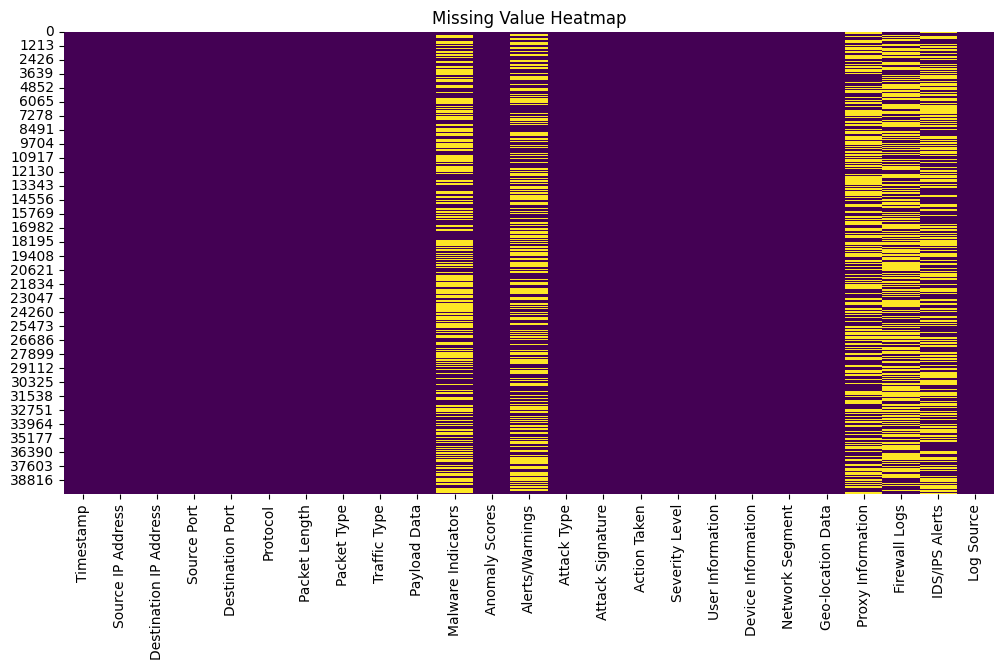

In [29]:
print("\nChecking Missing Values...")

missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage (%)': missing_percentage
})

missing_df = missing_df[missing_df['Missing Count'] > 0]

if len(missing_df) > 0:
    display(missing_df.sort_values(by='Missing Count', ascending=False))
else:
    print("Tidak ada missing values.")

# Visualisasi Missing Value
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Value Heatmap")
plt.show()

**CEK DUPLICATE DATA**


In [30]:
print("\nChecking Duplicate Data...")

duplicate = df.duplicated().sum()

print(f"Jumlah Duplicate Data: {duplicate}")

# Hapus duplicate jika diperlukan
df = df.drop_duplicates()

print("\nUkuran Dataset Setelah Hapus Duplicate:")
print(df.shape)


Checking Duplicate Data...
Jumlah Duplicate Data: 0

Ukuran Dataset Setelah Hapus Duplicate:
(40000, 25)


**CEK DISTRIBUSI TARGET**


Attack Type
DDoS         13428
Malware      13307
Intrusion    13265
Name: count, dtype: int64


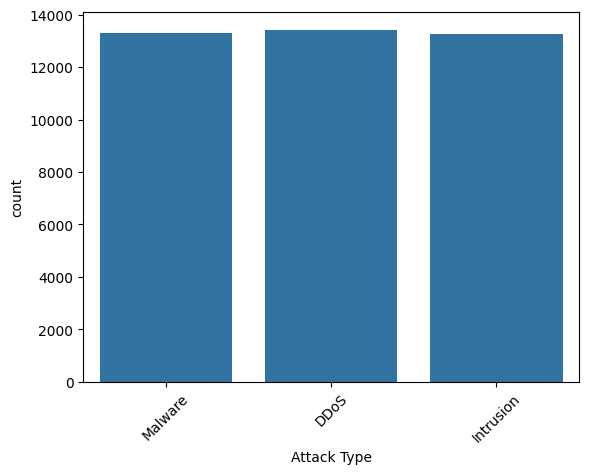

In [31]:
print(df['Attack Type'].value_counts())

sns.countplot(data=df, x='Attack Type')
plt.xticks(rotation=45)
plt.show()

**DATA VISUALIZATION**

TRAFFIC TYPE

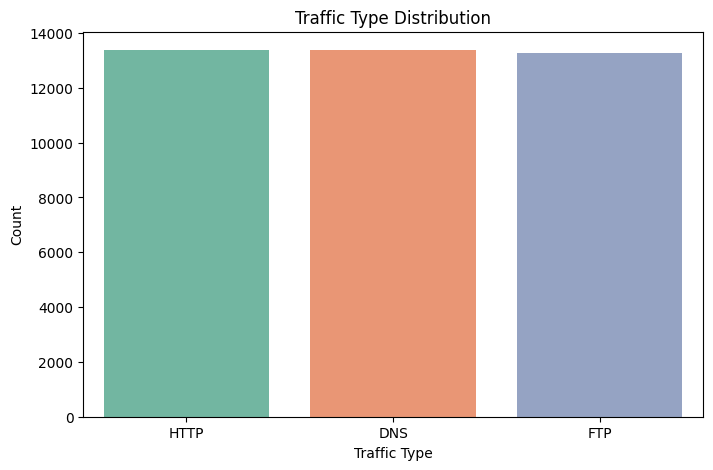

In [86]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Traffic Type', palette='Set2')

plt.title('Traffic Type Distribution')
plt.xlabel('Traffic Type')
plt.ylabel('Count')

plt.show()

PROTOCOL


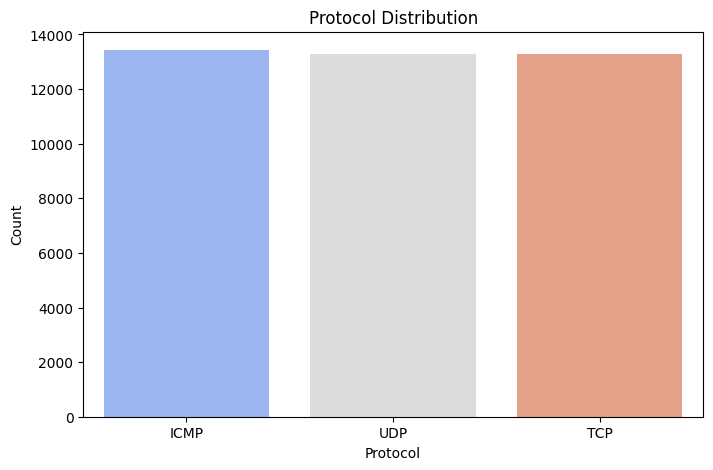

In [87]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Protocol', palette='coolwarm')

plt.title('Protocol Distribution')
plt.xlabel('Protocol')
plt.ylabel('Count')

plt.show()

SEVERITY LEVEL


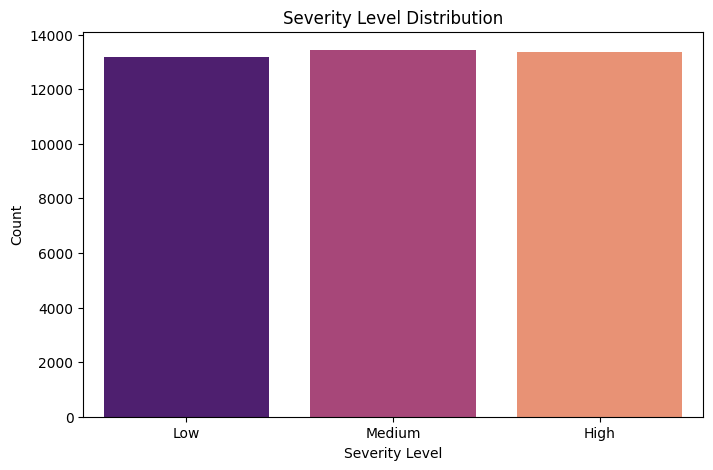

In [88]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Severity Level', palette='magma')

plt.title('Severity Level Distribution')
plt.xlabel('Severity Level')
plt.ylabel('Count')

plt.show()

CORRELATION


In [32]:
numeric_df = df.select_dtypes(include='number')

HISTOGRAM


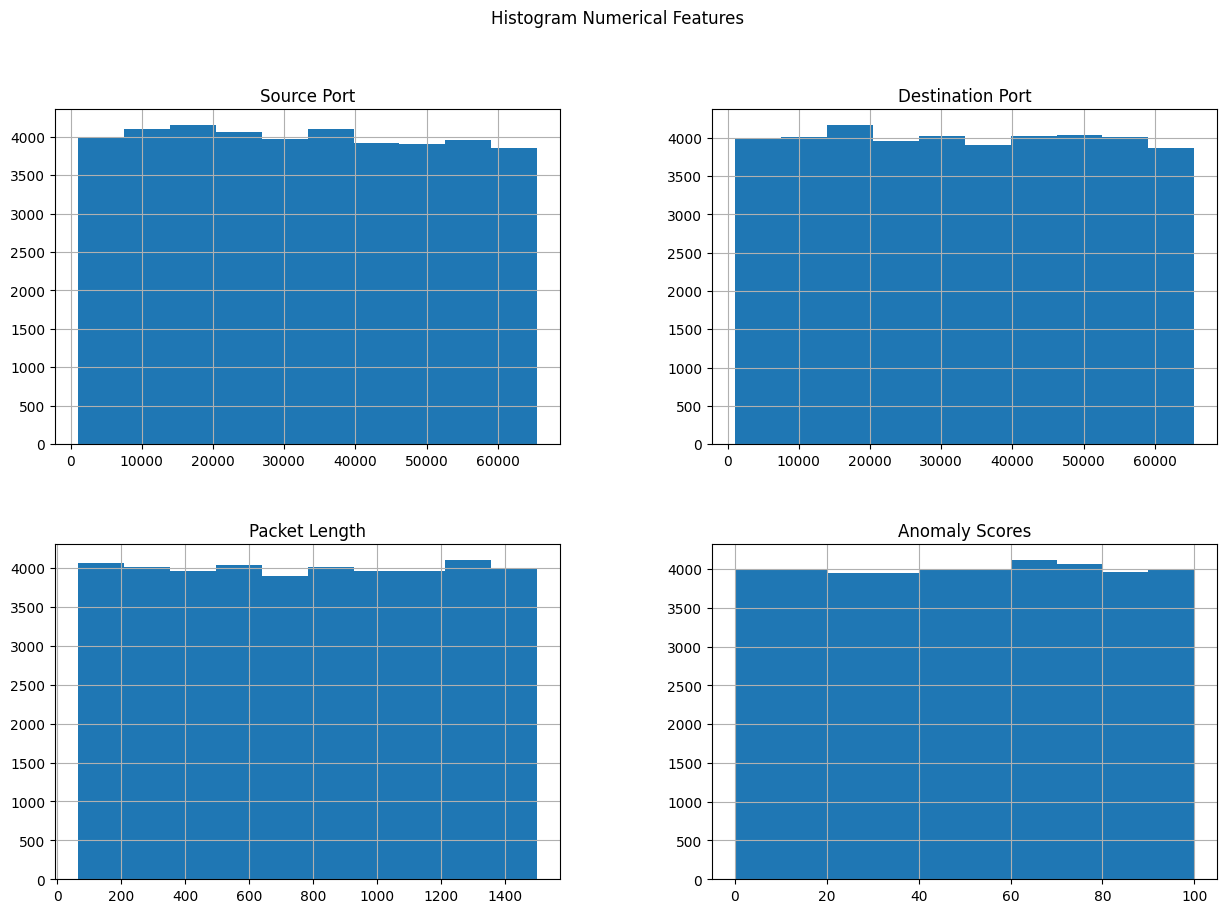

In [135]:
numeric_df.hist(figsize=(15,10))
plt.suptitle("Histogram Numerical Features")
plt.show()

**DATA PREPROCESSING**

PILIH KOLOM TEKS


In [34]:
text_column = 'Timestamp','Source IP Address', 'Source Port', 'Destination Port', 'Protocol', 'Packet Length', 'Packet Type', 'Traffic Type', 'Payload Data', 'Malware Indicators', 'Anomaly Scores', 'Alerts/Warnings', 'Attack Type', 'Attack Signature', 'Action Taken', 'Severity Level', 'User Information', 'Device Information', 'Network Segment', 'Geo-location Data', 'Proxy Information', 'Firewall Logs', 'IDS/IPS Alerts', 'Log Source'

In [35]:
print(df[list(text_column)].head())

             Timestamp Source IP Address  Source Port  Destination Port  \
0  2023-05-30 06:33:58     103.216.15.12        31225             17616   
1  2020-08-26 07:08:30    78.199.217.198        17245             48166   
2  2022-11-13 08:23:25      63.79.210.48        16811             53600   
3  2023-07-02 10:38:46     163.42.196.10        20018             32534   
4  2023-07-16 13:11:07     71.166.185.76         6131             26646   

  Protocol  Packet Length Packet Type Traffic Type  \
0     ICMP            503        Data         HTTP   
1     ICMP           1174        Data         HTTP   
2      UDP            306     Control         HTTP   
3      UDP            385        Data         HTTP   
4      TCP           1462        Data          DNS   

                                        Payload Data Malware Indicators  ...  \
0  Qui natus odio asperiores nam. Optio nobis ius...       IoC Detected  ...   
1  Aperiam quos modi officiis veritatis rem. Omni...       IoC D

LOWERCASE


In [36]:
df['lowercase'] = df[list(text_column)].apply(
    lambda row: ' '.join(row.dropna().astype(str)), 
    axis=1
)

df['lowercase'] = df['lowercase'].str.lower()

print("\n=== LOWERCASE ===")
# 3. Mengganti display() menjadi print() agar berjalan di VS Code
print(df[['lowercase']].head())


=== LOWERCASE ===
                                           lowercase
0  2023-05-30 06:33:58 103.216.15.12 31225 17616 ...
1  2020-08-26 07:08:30 78.199.217.198 17245 48166...
2  2022-11-13 08:23:25 63.79.210.48 16811 53600 u...
3  2023-07-02 10:38:46 163.42.196.10 20018 32534 ...
4  2023-07-16 13:11:07 71.166.185.76 6131 26646 t...


REMOVE NOISE


In [41]:
def remove_noise(text):

    # Hapus URL
    text = re.sub(r'http\S+|www\S+', '', text)

    # Hapus angka
    text = re.sub(r'\d+', '', text)

    # Hapus tanda baca
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Hapus karakter spesial
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['clean_text'] = df['lowercase'].apply(remove_noise)

print("\n=== REMOVE NOISE ===")
display(df[['clean_text']].head())


=== REMOVE NOISE ===


,clean_text
0,icmp data http qui natus odio asperiores nam o...
1,icmp data http aperiam quos modi officiis veri...
2,udp control http perferendis sapiente vitae so...
3,udp data http totam maxime beatae expedita exp...
4,tcp data dns odit nesciunt dolorem nisi iste i...


TOKENIZATION


In [46]:
def tokenize_text(text):
    return word_tokenize(text)

nltk.download('punkt_tab')

df['tokens'] = df['clean_text'].apply(tokenize_text)

print("\n=== TOKENIZATION ===")
display(df[['tokens']].head())

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Catrinee\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!



=== TOKENIZATION ===


,tokens
0,"[icmp, data, http, qui, natus, odio, asperiore..."
1,"[icmp, data, http, aperiam, quos, modi, offici..."
2,"[udp, control, http, perferendis, sapiente, vi..."
3,"[udp, data, http, totam, maxime, beatae, exped..."
4,"[tcp, data, dns, odit, nesciunt, dolorem, nisi..."


In [ ]:
stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

df['stopword_removed'] = df['tokens'].apply(remove_stopwords)

print("\n=== STOPWORD REMOVAL ===")
display(df[['stopword_removed']].head())


=== STOPWORD REMOVAL ===


,stopword_removed
0,"[icmp, data, http, qui, natus, odio, asperiore..."
1,"[icmp, data, http, aperiam, quos, modi, offici..."
2,"[udp, control, http, perferendis, sapiente, vi..."
3,"[udp, data, http, totam, maxime, beatae, exped..."
4,"[tcp, data, dns, odit, nesciunt, dolorem, nisi..."


In [50]:
import nltk

from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Catrinee\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Catrinee\AppData\Roaming\nltk_data...


True

STEMMING


In [56]:
stemmer = PorterStemmer()

def stemming(tokens):
    return [stemmer.stem(word) for word in tokens]

df['stemming'] = df['stopword_removed'].apply(stemming)

print("\n=== STEMMING ===")
display(df[['stemming']].head())


=== STEMMING ===


,stemming
0,"[icmp, data, http, qui, natu, odio, asperior, ..."
1,"[icmp, data, http, aperiam, quo, modi, officii..."
2,"[udp, control, http, perferendi, sapient, vita..."
3,"[udp, data, http, totam, maxim, beata, expedit..."
4,"[tcp, data, dn, odit, nesciunt, dolorem, nisi,..."


LEMMATIZATION


In [57]:
lemmatizer = WordNetLemmatizer()

def lemmatization(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

df['lemmatization'] = df['stopword_removed'].apply(lemmatization)

print("\n=== LEMMATIZATION ===")
display(df[['lemmatization']].head())


=== LEMMATIZATION ===


,lemmatization
0,"[icmp, data, http, qui, natus, odio, asperiore..."
1,"[icmp, data, http, aperiam, quos, modi, offici..."
2,"[udp, control, http, perferendis, sapiente, vi..."
3,"[udp, data, http, totam, maxime, beatae, exped..."
4,"[tcp, data, dns, odit, nesciunt, dolorem, nisi..."


In [58]:
df['final_text'] = df['lemmatization'].apply(lambda x: ' '.join(x))

print("\n=== FINAL PREPROCESSED TEXT ===")
display(df[['final_text']].head())


=== FINAL PREPROCESSED TEXT ===


,final_text
0,icmp data http qui natus odio asperiores nam o...
1,icmp data http aperiam quos modi officiis veri...
2,udp control http perferendis sapiente vitae so...
3,udp data http totam maxime beatae expedita exp...
4,tcp data dns odit nesciunt dolorem nisi iste i...


HASIL PREPROCESSING


In [59]:
print("\nContoh Sebelum dan Sesudah Preprocessing")

# Menggabungkan teks original dengan aman (membuang nilai NaN dan memaksa konversi ke string)
original_text_safe = df[list(text_column)].head().apply(
    lambda row: ' '.join(row.dropna().astype(str)), 
    axis=1
)

comparison = pd.DataFrame({
    'Original Text': original_text_safe,
    'Processed Text': df['final_text'].head()
})

# Menggunakan print() agar kompatibel dengan VS Code
print(comparison)


Contoh Sebelum dan Sesudah Preprocessing
                                       Original Text  \
0  2023-05-30 06:33:58 103.216.15.12 31225 17616 ...   
1  2020-08-26 07:08:30 78.199.217.198 17245 48166...   
2  2022-11-13 08:23:25 63.79.210.48 16811 53600 U...   
3  2023-07-02 10:38:46 163.42.196.10 20018 32534 ...   
4  2023-07-16 13:11:07 71.166.185.76 6131 26646 T...   

                                      Processed Text  
0  icmp data http qui natus odio asperiores nam o...  
1  icmp data http aperiam quos modi officiis veri...  
2  udp control http perferendis sapiente vitae so...  
3  udp data http totam maxime beatae expedita exp...  
4  tcp data dns odit nesciunt dolorem nisi iste i...  


**DATA PREPARATION**

In [60]:
df = df.dropna(subset=['Attack Type'])

CEK DATASET


In [61]:
print("Ukuran Dataset:")
print(df.shape)

print("\nKolom Dataset:")
print(df.columns)

Ukuran Dataset:
(40000, 32)

Kolom Dataset:
Index(['Timestamp', 'Source IP Address', 'Destination IP Address',
       'Source Port', 'Destination Port', 'Protocol', 'Packet Length',
       'Packet Type', 'Traffic Type', 'Payload Data', 'Malware Indicators',
       'Anomaly Scores', 'Alerts/Warnings', 'Attack Type', 'Attack Signature',
       'Action Taken', 'Severity Level', 'User Information',
       'Device Information', 'Network Segment', 'Geo-location Data',
       'Proxy Information', 'Firewall Logs', 'IDS/IPS Alerts', 'Log Source',
       'lowercase', 'clean_text', 'tokens', 'stopword_removed', 'stemming',
       'lemmatization', 'final_text'],
      dtype='str')


MENENTUKAN FITUR(X) DAN TARGET(Y)

In [62]:
y = df['Attack Type']

In [129]:
cols_to_drop = [
    'Timestamp',
    'Source IP Address',
    'Destination IP Address',
    'Payload Data',
    'User Information',

    # NLP Columns
    'lowercase',
    'clean_text',
    'tokens',
    'stopword_removed',
    'stemming',
    'lemmatization',
    'final_text',

    # Text columns lain
    'Malware Indicators',
    'Alerts/Warnings',
    'Attack Signature',
    'Device Information',
    'Geo-location Data',
    'Proxy Information',
    'Firewall Logs',
    'IDS/IPS Alerts',
    'Log Source'
]

X = df.drop(columns=cols_to_drop + ['Attack Type'])

DATA CATEGORIAL


In [130]:
if 'Timestamp' in X.columns:
    X['Timestamp'] = pd.to_datetime(X['Timestamp'])

    X['Hour'] = X['Timestamp'].dt.hour
    X['Day'] = X['Timestamp'].dt.day
    X['Month'] = X['Timestamp'].dt.month
    X['DayOfWeek'] = X['Timestamp'].dt.dayofweek

    X.drop('Timestamp', axis=1, inplace=True)

In [131]:
X = pd.get_dummies(
    X,
    columns=[
        'Protocol',
        'Packet Type',
        'Traffic Type',
        'Action Taken',
        'Severity Level',
        'Network Segment'
    ],
    drop_first=True
)

In [116]:
y = df['Attack Type']

target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)

print(target_encoder.classes_)
print("Jumlah kelas:", len(target_encoder.classes_))

['DDoS' 'Intrusion' 'Malware']
Jumlah kelas: 3


In [137]:
print(X_train.shape)
print(X_test.shape)

print(X_train.columns.tolist())

(32000, 15)
(8000, 15)
['Source Port', 'Destination Port', 'Packet Length', 'Anomaly Scores', 'Protocol_TCP', 'Protocol_UDP', 'Packet Type_Data', 'Traffic Type_FTP', 'Traffic Type_HTTP', 'Action Taken_Ignored', 'Action Taken_Logged', 'Severity Level_Low', 'Severity Level_Medium', 'Network Segment_Segment B', 'Network Segment_Segment C']


TRAIN TEST SPLIT


In [138]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(X_train.shape)
print(X_test.shape)

(32000, 15)
(8000, 15)


In [139]:
print(X_train.dtypes)

Source Port                    int64
Destination Port               int64
Packet Length                  int64
Anomaly Scores               float64
Protocol_TCP                    bool
Protocol_UDP                    bool
Packet Type_Data                bool
Traffic Type_FTP                bool
Traffic Type_HTTP               bool
Action Taken_Ignored            bool
Action Taken_Logged             bool
Severity Level_Low              bool
Severity Level_Medium           bool
Network Segment_Segment B       bool
Network Segment_Segment C       bool
dtype: object


SCALLING


In [140]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

CEK DISTRIBUSI TARGET


In [141]:
print("\nDistribusi Target:")
print(y.value_counts())



Distribusi Target:
Attack Type
DDoS         13428
Malware      13307
Intrusion    13265
Name: count, dtype: int64


**MODEL SELECTION**

In [142]:
import xgboost as xgb

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

models = {
    'XGBoost': xgb.XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='multi:softprob',
        num_class=len(target_encoder.classes_),
        eval_metric='mlogloss',
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=10,
        random_state=42
    ),
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42
    )
}


In [143]:
eval_set = [(X_train_scaled, y_train), (X_test_scaled, y_test)]

**MODEL TRAINING**

DEKLARASI MODEL


In [144]:
xgb_model = models["XGBoost"]

xgb_model.fit(
    X_train,
    y_train,
    eval_set=[
        (X_train, y_train),
        (X_test, y_test)
    ],
    verbose=True
)

[0]	validation_0-mlogloss:1.09726	validation_1-mlogloss:1.09877
[1]	validation_0-mlogloss:1.09607	validation_1-mlogloss:1.09877
[2]	validation_0-mlogloss:1.09458	validation_1-mlogloss:1.09871
[3]	validation_0-mlogloss:1.09326	validation_1-mlogloss:1.09867
[4]	validation_0-mlogloss:1.09209	validation_1-mlogloss:1.09865
[5]	validation_0-mlogloss:1.09045	validation_1-mlogloss:1.09869
[6]	validation_0-mlogloss:1.08917	validation_1-mlogloss:1.09870
[7]	validation_0-mlogloss:1.08754	validation_1-mlogloss:1.09875
[8]	validation_0-mlogloss:1.08609	validation_1-mlogloss:1.09883
[9]	validation_0-mlogloss:1.08468	validation_1-mlogloss:1.09885
[10]	validation_0-mlogloss:1.08340	validation_1-mlogloss:1.09885
[11]	validation_0-mlogloss:1.08217	validation_1-mlogloss:1.09895
[12]	validation_0-mlogloss:1.08068	validation_1-mlogloss:1.09893
[13]	validation_0-mlogloss:1.07962	validation_1-mlogloss:1.09895
[14]	validation_0-mlogloss:1.07834	validation_1-mlogloss:1.09888
[15]	validation_0-mlogloss:1.07677	

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

PROSES TRAINING


PREDIKSI DAN EVALUASI


In [145]:
y_pred_xgb = xgb_model.predict(X_test)

acc_xgb = accuracy_score(y_test, y_pred_xgb)

print(f"\n{'='*40}")
print(f"✅ AKURASI FINAL XGBOOST: {acc_xgb * 100:.2f}%")
print(f"{'='*40}\n")

print("Laporan Klasifikasi Detail:")
print(
    classification_report(
        y_test,
        y_pred_xgb,
        target_names=target_encoder.classes_
    )
)


✅ AKURASI FINAL XGBOOST: 32.74%

Laporan Klasifikasi Detail:
              precision    recall  f1-score   support

        DDoS       0.33      0.34      0.34      2686
   Intrusion       0.32      0.32      0.32      2653
     Malware       0.33      0.32      0.32      2661

    accuracy                           0.33      8000
   macro avg       0.33      0.33      0.33      8000
weighted avg       0.33      0.33      0.33      8000



In [146]:
# Random Forest
rf_model = models['Random Forest']
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

print(f"\n{'='*40}")
print(f" ✅ AKURASI FINAL RANDOM FOREST: {acc_rf * 100:.2f}%")
print(f"{'='*40}\n")

print("Laporan Klasifikasi Detil (Random Forest):")
print(classification_report(y_test, y_pred_rf, target_names=target_encoder.classes_))



 ✅ AKURASI FINAL RANDOM FOREST: 32.94%

Laporan Klasifikasi Detil (Random Forest):
              precision    recall  f1-score   support

        DDoS       0.33      0.36      0.34      2686
   Intrusion       0.33      0.31      0.32      2653
     Malware       0.32      0.32      0.32      2661

    accuracy                           0.33      8000
   macro avg       0.33      0.33      0.33      8000
weighted avg       0.33      0.33      0.33      8000



In [147]:
# Decision Tree
dt_model = models['Decision Tree']
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)

print(f"\n{'='*40}")
print(f" ✅ AKURASI FINAL DECISION TREE: {acc_dt * 100:.2f}%")
print(f"{'='*40}\n")

print("Laporan Klasifikasi Detil (Decision Tree):")
print(classification_report(y_test, y_pred_dt, target_names=target_encoder.classes_))



 ✅ AKURASI FINAL DECISION TREE: 33.20%

Laporan Klasifikasi Detil (Decision Tree):
              precision    recall  f1-score   support

        DDoS       0.34      0.70      0.45      2686
   Intrusion       0.33      0.20      0.25      2653
     Malware       0.32      0.09      0.14      2661

    accuracy                           0.33      8000
   macro avg       0.33      0.33      0.28      8000
weighted avg       0.33      0.33      0.28      8000



In [148]:
# Logistic Regression
lr_model = models['Logistic Regression']
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)
acc_lr = accuracy_score(y_test, y_pred_lr)

print(f"\n{'='*40}")
print(f" ✅ AKURASI FINAL LOGISTIC REGRESSION: {acc_lr * 100:.2f}%")
print(f"{'='*40}\n")

print("Laporan Klasifikasi Detil (Logistic Regression):")
print(classification_report(y_test, y_pred_lr, target_names=target_encoder.classes_))


 ✅ AKURASI FINAL LOGISTIC REGRESSION: 34.24%

Laporan Klasifikasi Detil (Logistic Regression):
              precision    recall  f1-score   support

        DDoS       0.35      0.44      0.39      2686
   Intrusion       0.33      0.25      0.28      2653
     Malware       0.34      0.33      0.34      2661

    accuracy                           0.34      8000
   macro avg       0.34      0.34      0.34      8000
weighted avg       0.34      0.34      0.34      8000



In [149]:
import pandas as pd

results_table = []
trained_models = {}

results_table.append(['XGBoost', acc_xgb])
trained_models['XGBoost'] = xgb_model

results_table.append(['Random Forest', acc_rf])
trained_models['Random Forest'] = rf_model

results_table.append(['Decision Tree', acc_dt])
trained_models['Decision Tree'] = dt_model

results_table.append(['Logistic Regression', acc_lr])
trained_models['Logistic Regression'] = lr_model

In [150]:
result_df = pd.DataFrame(results_table, columns=['Model', 'Accuracy'])
result_df['Accuracy (%)'] = result_df['Accuracy'] * 100
result_df = result_df.sort_values('Accuracy', ascending=False)

print("=== PERINGKAT AKURASI MODEL ===")
print(result_df[['Model', 'Accuracy (%)']].to_string(index=False))

best_model_name = result_df.iloc[0]['Model']
best_model = trained_models[best_model_name]

print('\nModel Terbaik:', best_model_name)

=== PERINGKAT AKURASI MODEL ===
              Model  Accuracy (%)
Logistic Regression       34.2375
      Decision Tree       33.2000
      Random Forest       32.9375
            XGBoost       32.7375

Model Terbaik: Logistic Regression


In [151]:
if best_model_name == 'Logistic Regression':
    final_pred = best_model.predict(X_test_scaled)
else:
    final_pred = best_model.predict(X_test)

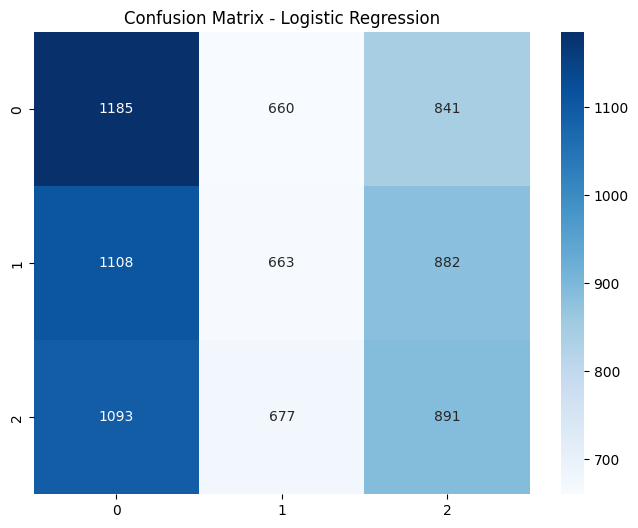

In [152]:
plt.figure(figsize=(8,6))
sns.heatmap(
    confusion_matrix(y_test, final_pred),
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

In [153]:
print(classification_report(
    y_test,
    final_pred,
    target_names=target_encoder.classes_
))

              precision    recall  f1-score   support

        DDoS       0.35      0.44      0.39      2686
   Intrusion       0.33      0.25      0.28      2653
     Malware       0.34      0.33      0.34      2661

    accuracy                           0.34      8000
   macro avg       0.34      0.34      0.34      8000
weighted avg       0.34      0.34      0.34      8000



In [154]:
results = xgb_model.evals_result()
epochs = len(results['validation_0']['mlogloss'])
x_axis = range(epochs)

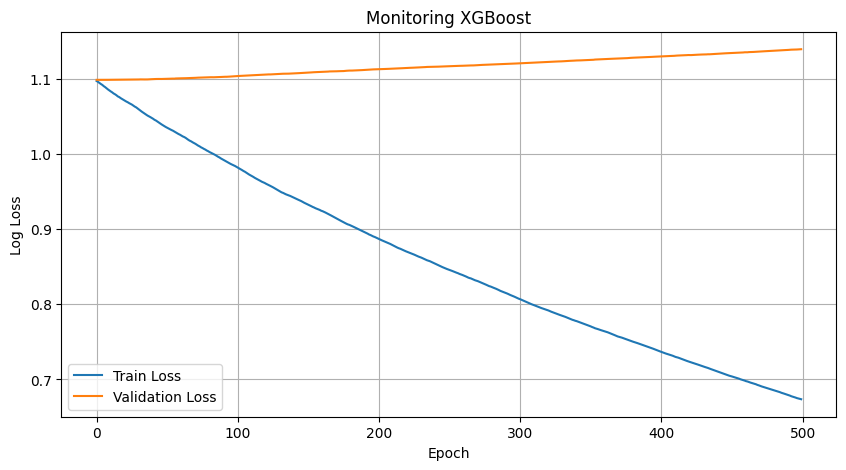

In [155]:
plt.figure(figsize=(10,5))
plt.plot(x_axis, results['validation_0']['mlogloss'])
plt.plot(x_axis, results['validation_1']['mlogloss'])
plt.legend(['Train Loss','Validation Loss'])
plt.xlabel('Epoch')
plt.ylabel('Log Loss')
plt.title('Monitoring XGBoost')
plt.grid(True)
plt.show()

In [156]:
le_target = LabelEncoder()
y_train_encoded = le_target.fit_transform(y_train)
y_test_encoded = le_target.transform(y_test)


**MODEL EVALUATION**


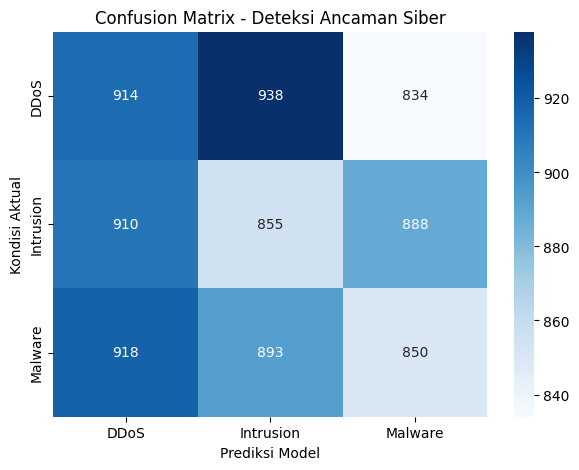

In [157]:
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_encoder.classes_,
    yticklabels=target_encoder.classes_
)

plt.title('Confusion Matrix - Deteksi Ancaman Siber')
plt.xlabel('Prediksi Model')
plt.ylabel('Kondisi Aktual')
plt.show()

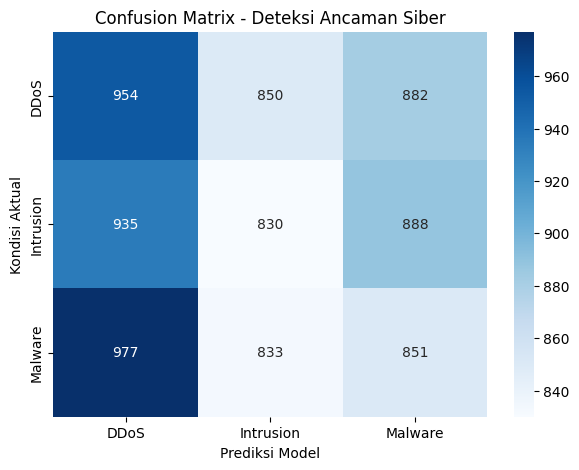

In [158]:
y_pred_rf = rf_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_encoder.classes_,
    yticklabels=target_encoder.classes_
)

plt.title('Confusion Matrix - Deteksi Ancaman Siber')
plt.xlabel('Prediksi Model')
plt.ylabel('Kondisi Aktual')
plt.show()

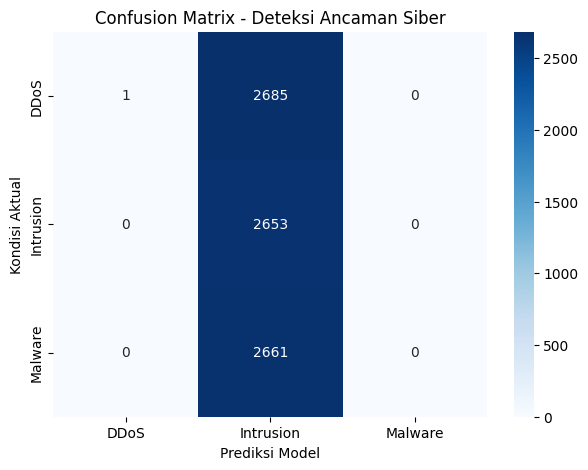

In [159]:
y_pred_lr = lr_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_encoder.classes_,
    yticklabels=target_encoder.classes_
)

plt.title('Confusion Matrix - Deteksi Ancaman Siber')
plt.xlabel('Prediksi Model')
plt.ylabel('Kondisi Aktual')
plt.show()

In [136]:
joblib.dump(best_model, 'best_model.pkl')
joblib.dump(scaler, "scaler.pkl")
joblib.dump(target_encoder, "target_encoder.pkl")
joblib.dump(label_encoders, "label_encoders.pkl")

['label_encoders.pkl']

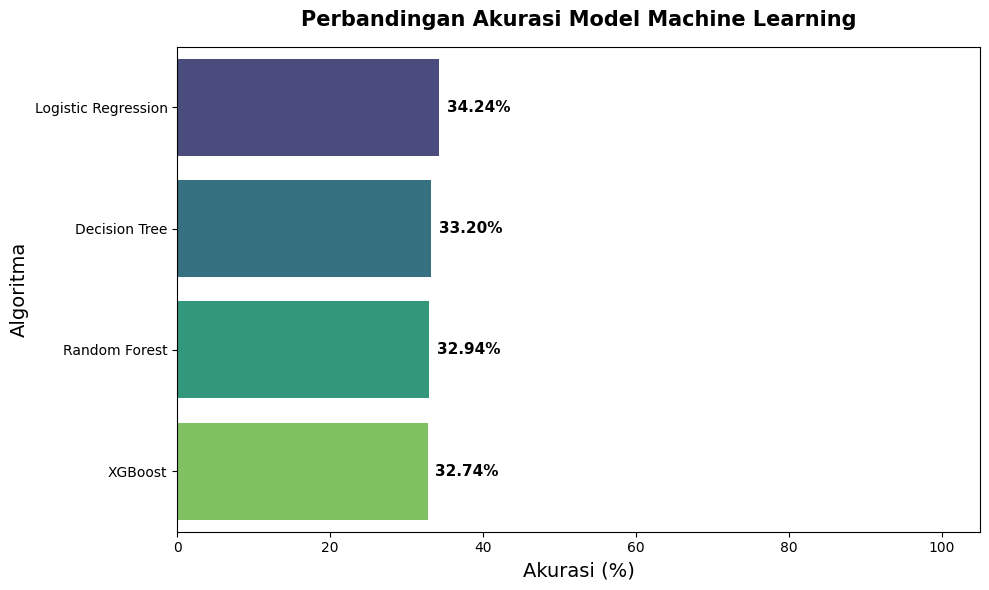

In [160]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur ukuran grafik
plt.figure(figsize=(10, 6))

# Membuat bar chart
ax = sns.barplot(
    x='Accuracy (%)', 
    y='Model', 
    data=result_df, 
    palette='viridis'
)

# Menambahkan judul dan label
plt.title('Perbandingan Akurasi Model Machine Learning', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Akurasi (%)', fontsize=14)
plt.ylabel('Algoritma', fontsize=14)

# Mengatur batas sumbu X agar mentok di 100%
plt.xlim(0, 105) 

# Menambahkan angka persentase di ujung setiap bar agar lebih informatif
for p in ax.patches:
    width = p.get_width()
    plt.text(
        width + 1,       # Posisi teks sedikit di kanan bar
        p.get_y() + p.get_height() / 2, # Posisi tengah secara vertikal
        f'{width:.2f}%', # Format angka 2 desimal
        ha='left', 
        va='center',
        fontsize=11,
        fontweight='bold'
    )

# Menampilkan grafik
plt.tight_layout()
plt.show()